In [ ]:
#Luis Miguel Chaves Espinosa

# Customer segmentation of a Dataset

based on: https://www.kaggle.com/code/karnikakapoor/customer-segmentation-clustering

In [3]:
import kagglehub
imakash3011_customer_personality_analysis_path = kagglehub.dataset_download('imakash3011/customer-personality-analysis')

print('Data source import complete.')

100%|██████████| 62.0k/62.0k [00:00<00:00, 46.0MB/s]

Extracting files...
Data source import complete.


### Save Data to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import shutil
import os

# Source path of the downloaded dataset (from kagglehub)
source_path = imakash3011_customer_personality_analysis_path

# Destination path
destination_dir = '/content/drive/My Drive/Colab Notebooks/customer_personality_data'

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Copy the contents of the downloaded dataset directory to Google Drive
shutil.copytree(source_path, os.path.join(destination_dir, os.path.basename(source_path)), dirs_exist_ok=True)
drive_dataset_path = os.path.join(destination_dir, os.path.basename(source_path), 'marketing_campaign.csv')
print(f'Dataset copied to: {destination_dir}/{os.path.basename(source_path)}')

Dataset copied to: /content/drive/My Drive/Colab Notebooks/customer_personality_data/1


In [ ]:
# checking the data composition
with open (drive_dataset_path, 'r') as file:
  for i in range(5):
    line = file.readline()
    print(repr(line))

'ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse\n'
'5524\t1957\tGraduation\tSingle\t58138\t0\t0\t04-09-2012\t58\t635\t88\t546\t172\t88\t88\t3\t8\t10\t4\t7\t0\t0\t0\t0\t0\t0\t3\t11\t1\n'
'2174\t1954\tGraduation\tSingle\t46344\t1\t1\t08-03-2014\t38\t11\t1\t6\t2\t1\t6\t2\t1\t1\t2\t5\t0\t0\t0\t0\t0\t0\t3\t11\t0\n'
'4141\t1965\tGraduation\tTogether\t71613\t0\t0\t21-08-2013\t26\t426\t49\t127\t111\t21\t42\t1\t8\t2\t10\t4\t0\t0\t0\t0\t0\t0\t3\t11\t0\n'
'6182\t1984\tGraduation\tTogether\t26646\t1\t0\t10-02-2014\t26\t11\t4\t20\t10\t3\t5\t2\t2\t0\t4\t6\t0\t0\t0\t0\t0\t0\t3\t11\t0\n'


In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Load the dataset from Google Drive
with open(drive_dataset_path, 'r') as file:
    data = pd.read_csv(file, sep="\t")

Identify customer segments to improve business relevance through data analysis.









### IMPORTING LIBRARIES

In [7]:
#Importing the Libraries
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

### LOADING DATA

In [8]:
#Previewing the dataset
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Attributes
---
* People

      ID: Customer's unique identifier

      Year_Birth: Customer's birth year

      Education: Customer's education level

      Marital_Status: Customer's marital status

      Income: Customer's yearly household income

      Kidhome: Number of children in customer's household

      Teenhome: Number of teenagers in customer's household

      Dt_Customer: Date of customer's enrollment with the company

      Recency: Number of days since customer's last purchase

      Complain: 1 if the customer complained in the last 2 years, 0 otherwise
---

* Products

      MntWines: Amount spent on wine in last 2 years

      MntFruits: Amount spent on fruits in last 2 years

      MntMeatProducts: Amount spent on meat in last 2 years

      MntFishProducts: Amount spent on fish in last 2 years

      MntSweetProducts: Amount spent on sweets in last 2 years

      MntGoldProds: Amount spent on gold in last 2 years
---
* Promotion

      NumDealsPurchases: Number of purchases made with a discount

      AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

      AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

      AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

      AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

      AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

      Response: 1 if customer accepted the offer in the last campaign, 0 otherwise
---
* Place

      NumWebPurchases: Number of purchases made through the company’s website

      NumCatalogPurchases: Number of purchases made using a catalogue

      NumStorePurchases: Number of purchases made directly in stores

      NumWebVisitsMonth: Number of visits to company’s website in the last month

### Data Cleaning

In [9]:
#Information on features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

**From the above output, we can conclude and note that:**

* There are missing values in income
* Dt_Customer that indicates the date a customer joined the database is not parsed as DateTime
* There are some categorical features in our data frame; as there are some features in dtype: object). So we will need to encode them into numeric forms later.

First of all, for the missing values, I am simply going to drop the rows that have missing income values.

In [10]:
#To remove the NA values
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


creating a feature out of **"Dt_Customer"** that indicates the number of days a customer is registered in the firm's database. However, in order to keep it simple, taking this value relative to the most recent customer in the record.

Checking the newest and oldest recorded dates.

In [11]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
dates = []
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)
#Dates of the newest and oldest recorded customer
print("The newest customer's enrolment date in therecords:",max(dates))
print("The oldest customer's enrolment date in the records:",min(dates))


The newest customer's enrolment date in therecords: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30


Creating a feature **("Customer_For")** of the number of days the customers started to shop in the store relative to the last recorded date

In [12]:
#Created a feature "Customer_For"
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)
data["Customer_For"] = days
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

Now we will be exploring the unique values in the categorical features to get a clear idea of the data.  

In [13]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


* Extract the **"Age"** of a customer by the **"Year_Birth"** indicating the birth year of the respective person.
* Create another feature **"Spent"** indicating the total amount spent by the customer in various categories over the span of two years.
* Create another feature **"Living_With"** out of **"Marital_Status"** to extract the living situation of couples.
* Create a feature **"Children"** to indicate total children in a household that is, kids and teenagers.
* To get further clarity of household, Creating feature indicating **"Family_Size"**
* Create a feature **"Is_Parent"** to indicate parenthood status
* Lastly, I will create three categories in the **"Education"** by simplifying its value counts.
* Dropping some of the redundant features

In [14]:
#Feature Engineering
#Age of customer today
data["Age"] = 2026-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

/tmp/ipykernel_2514/3323003154.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]


In [15]:
data.head()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,Graduate,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,57283200000000000,69,1617,Alone,0,1,0
1,Graduate,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,9763200000000000,72,27,Alone,2,3,1
2,Graduate,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,26956800000000000,61,776,Partner,0,2,0
3,Graduate,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,12009600000000000,42,53,Partner,1,3,1
4,Postgraduate,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,13910400000000000,45,422,Partner,1,3,1


Now that we have some new features let's have a look at the data's stats.

In [16]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,3.054423e+16,57.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,30.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.555200e+16,49.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,56.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,67.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,133.000000,2525.000000,3.000000,5.000000,1.000000


The above stats show some discrepancies in mean Income and Age and max Income and age.

Do note that  max-age is 133 years, As I calculated the age that would be today (i.e. 2026) and the data is old.

I must take a look at the broader view of the data.
Ploting some of the selected features.

In [54]:
pallet = ["#7FB3D5", "#F1A66A", "#A9D6B8", "#D5A6BD", "#C9B6E4", "#F4D35E"]
pall = ["#7FB3D5", "#F1A66A", "#A9D6B8", "#D5A6BD"]
cmap = colors.ListedColormap(pallet)

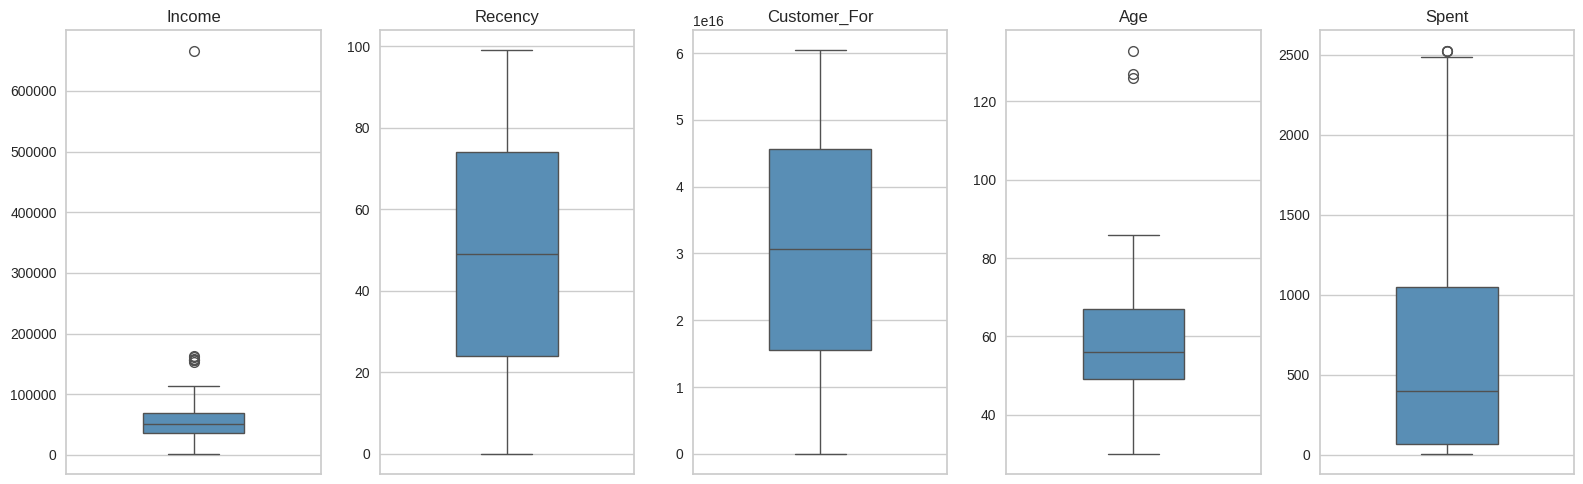

In [18]:
vars_ = ["Income", "Recency", "Customer_For", "Age", "Spent"]

fig, axes = plt.subplots(1, 5, figsize=(16,5))
for ax, v in zip(axes, vars_):
    sns.boxplot(y=data[v], ax=ax, color="#4A90C4", width=0.4)
    ax.set_title(v)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Outliers

In [20]:
#Checking outliers %
outliers_age = data[data["Age"] > 90]
print("Outliers more tan 90 years old: ")
display(outliers_age)
outliers_income = data[data["Income"] > 300000]
print("Outliers income more than 300000 USD: ")
display(outliers_income )

Outliers more tan 90 years old: 


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
192,Undergraduate,36640.0,1,0,99,15,6,8,7,4,...,0,1,0,23846400000000000,126,65,Alone,1,2,1
239,Undergraduate,60182.0,0,1,23,8,0,5,7,0,...,0,0,0,3715200000000000,133,22,Alone,1,2,1
339,Postgraduate,83532.0,0,0,36,755,144,562,104,64,...,0,0,0,23846400000000000,127,1853,Partner,0,2,0


Outliers income more than 300000 USD: 


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
2233,Graduate,666666.0,1,0,23,9,14,18,8,1,...,0,0,0,33868800000000000,49,62,Partner,1,3,1


In [21]:
#Checking outliers %
print(f"The age outliers represents: {(((data["Age"]>90).sum()/len(data))*100):.2f}%")
print(f"The income outliers represents: {(((data["Income"]>200000).sum()/len(data))*100):.2f}%")

The age outliers represents: 0.14%
The income outliers represents: 0.05%


In [22]:
#Dropping the outliers by setting a cap on Age and income.
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


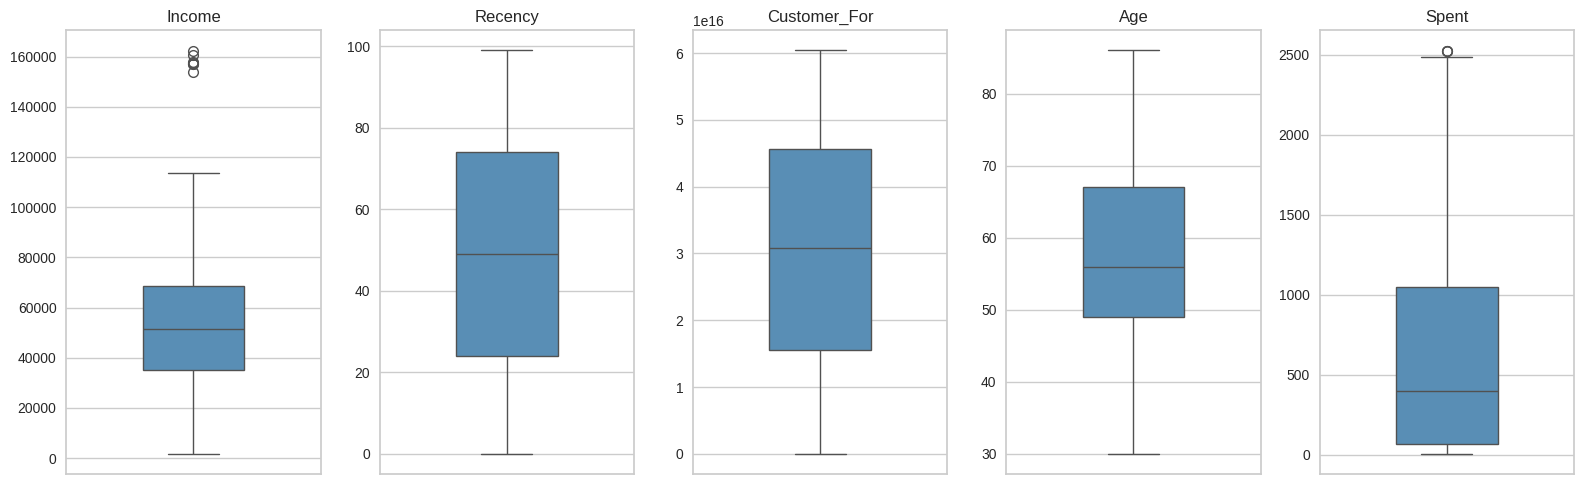

In [23]:
vars_ = ["Income", "Recency", "Customer_For", "Age", "Spent"]

fig, axes = plt.subplots(1, 5, figsize=(16,5))
for ax, v in zip(axes, vars_):
    sns.boxplot(y=data[v], ax=ax, color="#4A90C4", width=0.4)
    ax.set_title(v)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

Next, let us look at the correlation amongst the features.
(Excluding the categorical attributes at this point)

<Axes: >

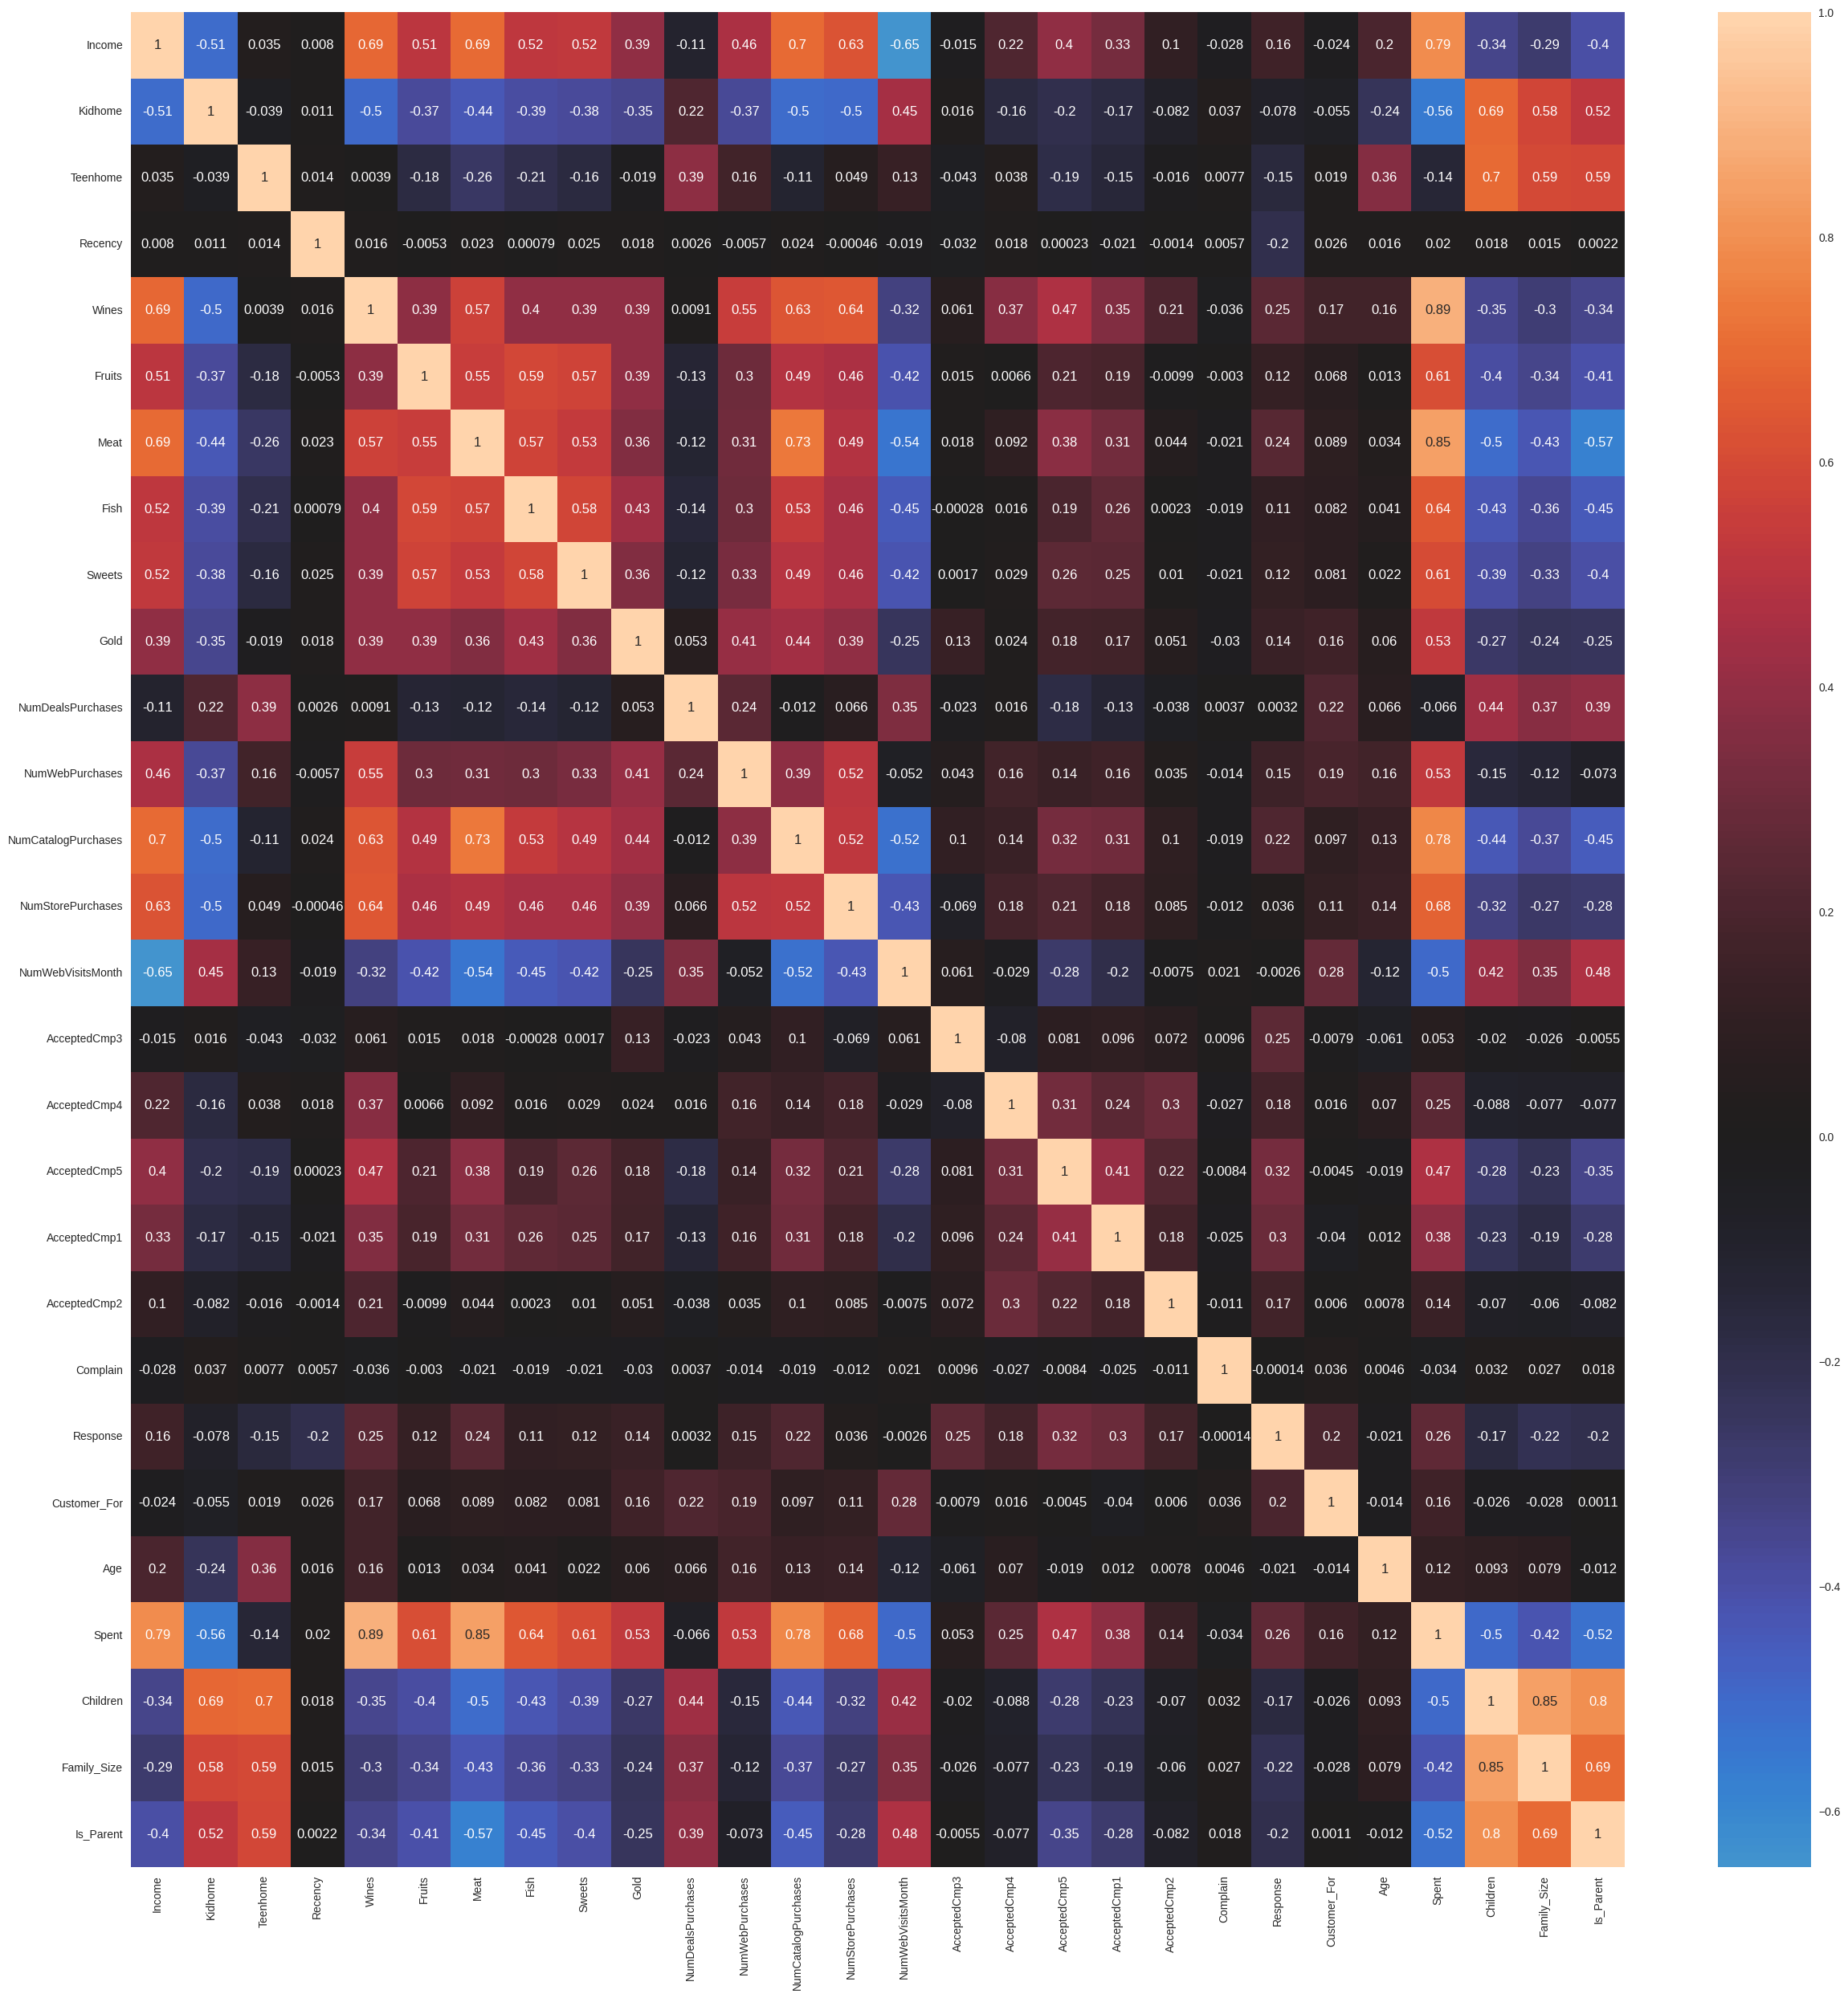

In [24]:
#correlation matrix
corrmat= data.corr(numeric_only=True)
plt.figure(figsize=(30,30))
sns.heatmap(corrmat,annot=True, center=0)

### DATA PREPROCESSING

In this section, I will be preprocessing the data to perform clustering operations.

**The following steps are applied to preprocess the data:**

* Label encoding the categorical features
* Scaling the features using the standard scaler
* Creating a subset dataframe for dimensionality reduction

In [25]:
#Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [26]:
#Label Encoding the object dtypes.
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)

print("All features are now numerical")

All features are now numerical


In [27]:
#Creating a copy of data
ds = data.copy()
# creating a subset of dataframe by dropping the features on deals accepted and promotions
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)
#Scaling
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
print("All features are now scaled")

All features are now scaled


In [28]:
#Scaled data to be used for reducing the dimensionality
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


### DIMENSIONALITY REDUCTION

**Principal component analysis (PCA)** is a technique for reducing the dimensionality of such datasets, increasing interpretability but at the same time minimizing information loss.

**Steps in this section:**
* Dimensionality reduction with PCA
* Plotting the reduced dataframe

**Dimensionality reduction with PCA**

For this project, the reduced dimensions will be 3.

In [30]:
#Initiating PCA to reduce dimentions features to 3
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2212.0,5.781993e-17,2.878602,-5.978124,-2.539470,-0.781595,2.386380,7.452915
col2,2212.0,6.424437e-17,1.709469,-4.194757,-1.323929,-0.173721,1.234851,6.168189
col3,2212.0,1.244735e-17,1.231687,-3.625248,-0.853713,-0.050842,0.863974,6.750458


### CLUSTERING

Now that I have reduced the attributes to three dimensions, I will be performing clustering via Agglomerative clustering. Agglomerative clustering is a hierarchical clustering method.  It involves merging examples until the desired number of clusters is achieved.

**Steps involved in the Clustering**
* Elbow Method to determine the number of clusters to be formed
* Clustering via Agglomerative Clustering
* Examining the clusters formed via scatter plot

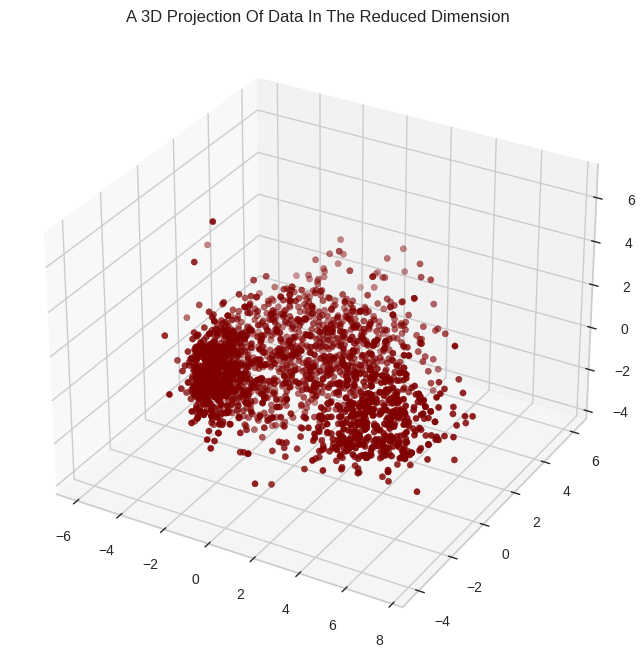

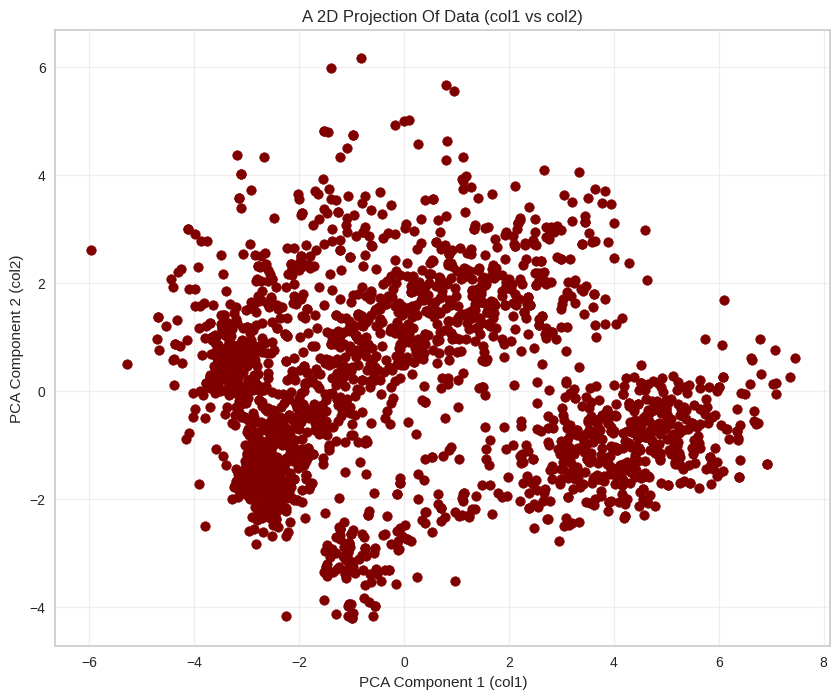

In [61]:
# A 3D Projection Of Data In The Reduced Dimension
x = PCA_ds["col1"]
y = PCA_ds["col2"]
z = PCA_ds["col3"]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x, y, z, c="maroon", marker="o")
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

# A 2D Projection Of Data (First two PCA components)
fig = plt.figure(figsize=(10,8))
# Sin especificar projection, Matplotlib usa 2D por defecto
plt.scatter(x, y, c="maroon", marker="o")
plt.title("A 2D Projection Of Data (col1 vs col2)")
plt.xlabel("PCA Component 1 (col1)")
plt.ylabel("PCA Component 2 (col2)")
plt.grid(True, alpha=0.3)
plt.show()

Elbow Method to determine the number of clusters to be formed:


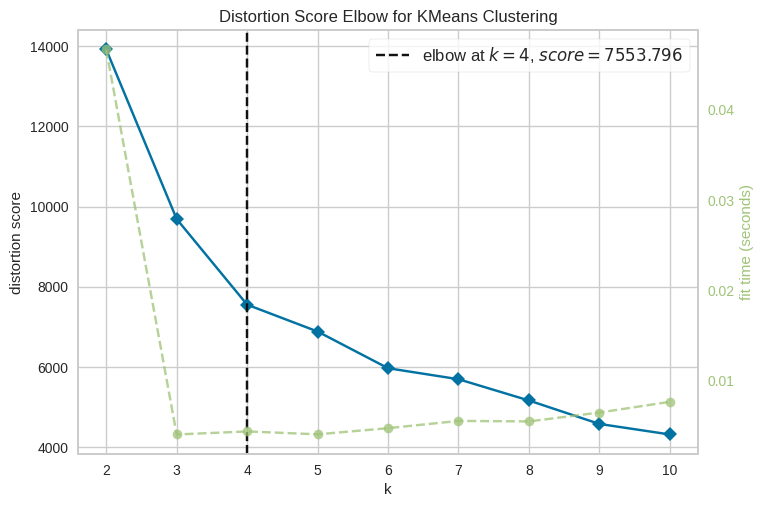

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [32]:
# Quick examination of elbow method to find numbers of clusters to make.
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

In [51]:
#K-means clustering
KM = KMeans(n_clusters=4, random_state=42, n_init=10)
#fit model and predict clusters
yhat_KM = KM.fit_predict(PCA_ds)
#Storing the KMeans labels separately, so the Agglomerative "Clusters" column used later stays untouched
PCA_ds["Clusters_KMeans"] = yhat_KM
#Adding the Clusters feature to the orignal dataframe.
data["Clusters_KMeans"]= yhat_KM

print("KMeans cluster sizes:")
print(pd.Series(yhat_KM).value_counts().sort_index())

KMeans cluster sizes:
0    498
1    608
2    570
3    536
Name: count, dtype: int64


The above cell indicates that four will be an optimal number of clusters for this data.
Next, we will be fitting the Agglomerative Clustering Model to get the final clusters.

In [52]:
#Initiating the Agglomerative Clustering model
AC = AgglomerativeClustering(n_clusters=4)
# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC
#Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= yhat_AC

print("Agglomerative cluster sizes:")
print(pd.Series(yhat_AC).value_counts().sort_index())

Agglomerative cluster sizes:
0    577
1    601
2    498
3    536
Name: count, dtype: int64


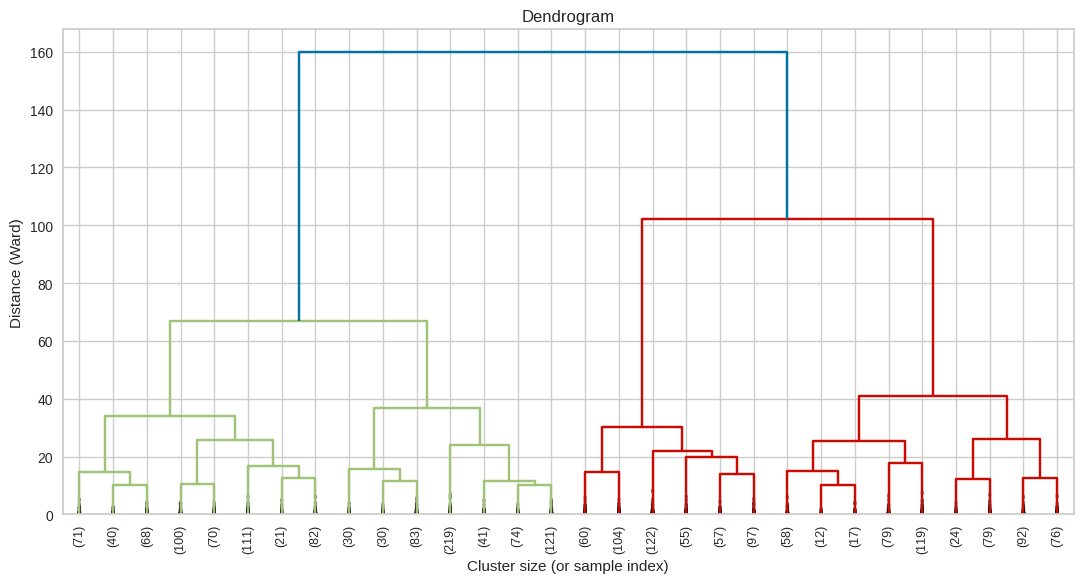

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage

#Using the same linkage (ward) that AgglomerativeClustering uses by default
Z = linkage(PCA_ds[["col1","col2","col3"]], method='ward')

plt.figure(figsize=(11,6))
plt.title("Dendrogram")
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

To examine the clusters formed let's have a look at the 3-D distribution of the clusters.

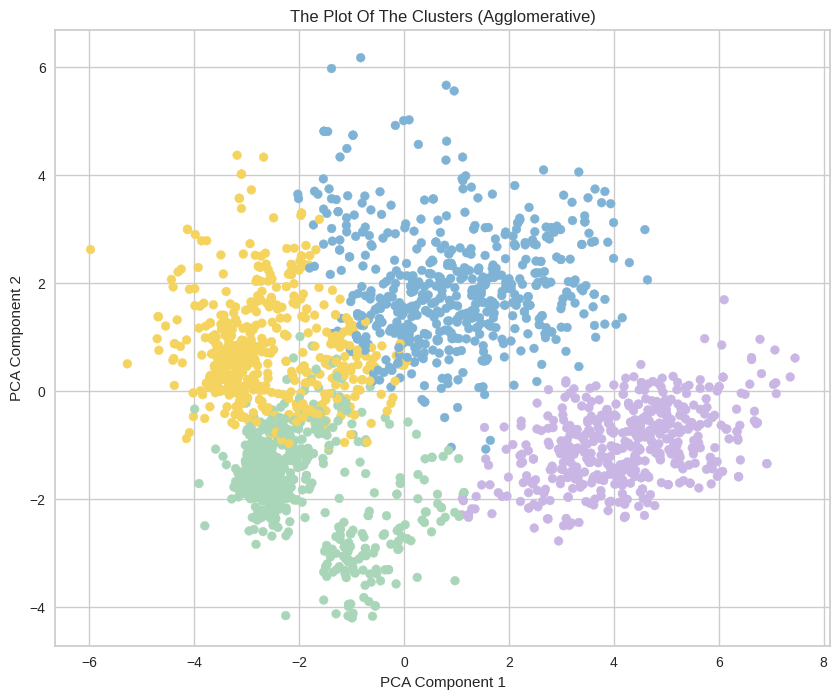

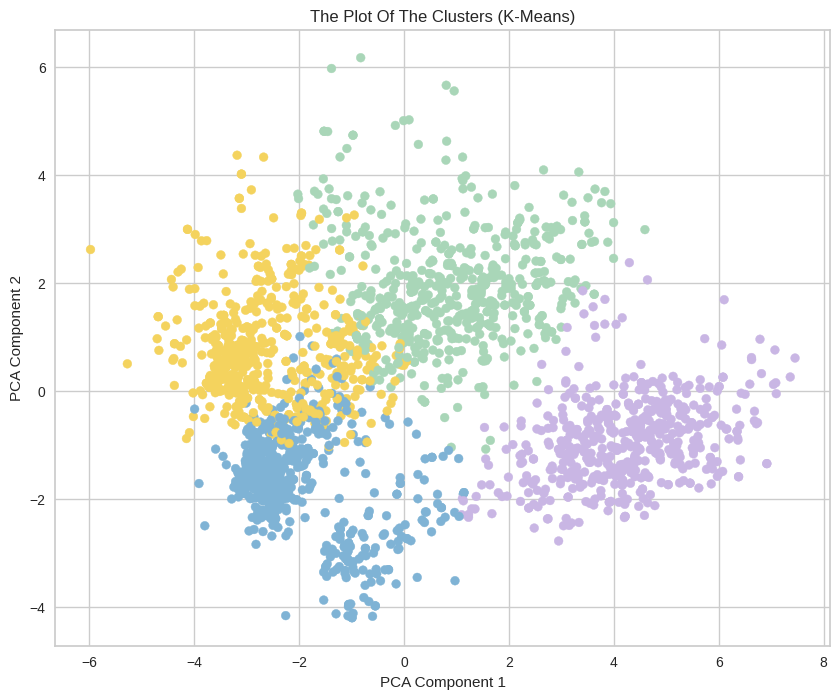

In [44]:
# Plotting the clusters (Agglomerative)
plt.figure(figsize=(10,8))
# Al no especificar projection, Matplotlib asume 2D por defecto
plt.scatter(x, y, s=40, c=PCA_ds["Clusters"], marker='o', cmap=cmap)
plt.title("The Plot Of The Clusters (Agglomerative)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Plotting the clusters (K-Means)
plt.figure(figsize=(10,8))
plt.scatter(x, y, s=40, c=PCA_ds["Clusters_KMeans"], marker='o', cmap=cmap)
plt.title("The Plot Of The Clusters (K-Means)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

### EVALUATING MODELS

Since this is an unsupervised clustering. We do not have a tagged feature to evaluate or score our model. The purpose of this section is to study the patterns in the clusters formed and determine the nature of the clusters' patterns.

For that, we will be having a look at the data in light of clusters via exploratory data analysis and drawing conclusions.

**Firstly, let us have a look at the group distribution of clustring**

/tmp/ipykernel_2514/2633518661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data["Clusters"], palette= pal)


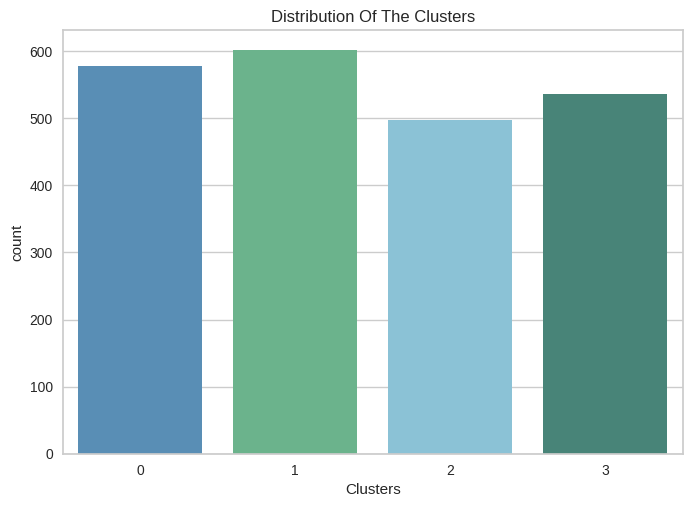

In [55]:
#Plotting countplot of clusters
pal = ["#4A90C4", "#5FBF8B", "#7EC8E3", "#3E8E7E"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

The clusters seem to be fairly distributed.

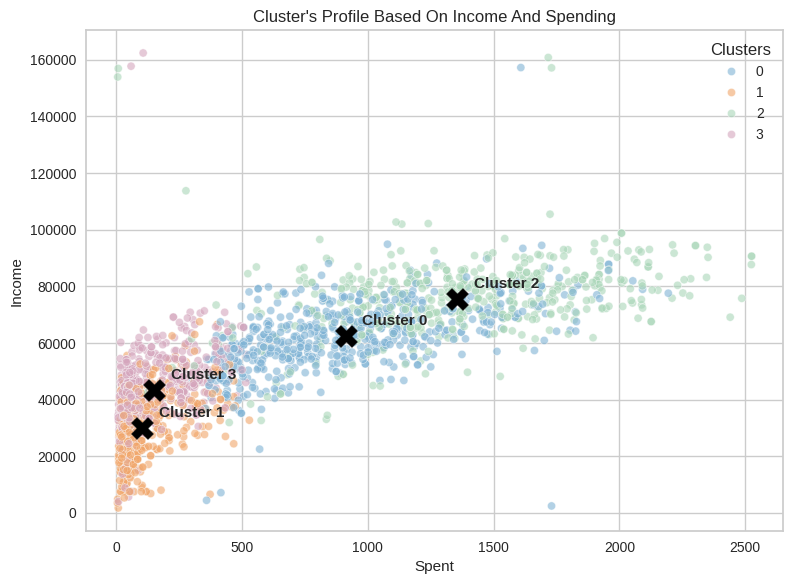

In [62]:
plt.figure(figsize=(9,6.5))
pl = sns.scatterplot(data=data, x="Spent", y="Income", hue="Clusters", palette=pall, alpha=0.6, s=35)

# Mark each cluster's center (mean) with a large X and label
means = data.groupby("Clusters")[["Spent","Income"]].mean()
for cl, row in means.iterrows():
    plt.scatter(row["Spent"], row["Income"], color="black", marker="X", s=250, zorder=5)
    plt.annotate(f"Cluster {cl}", (row["Spent"], row["Income"]),
                 textcoords="offset points", xytext=(12,8), fontsize=11, fontweight="bold")

pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend(title="Clusters")
plt.show()

**Income vs Spending plot shows the clusters pattern**

* **Cluster 1** lowest income& lowest spending
* **Cluster 3** below average income & low spending
* **Cluster 0** above average income & mid-high spending
* **Cluster 2** highest income  & highest spending

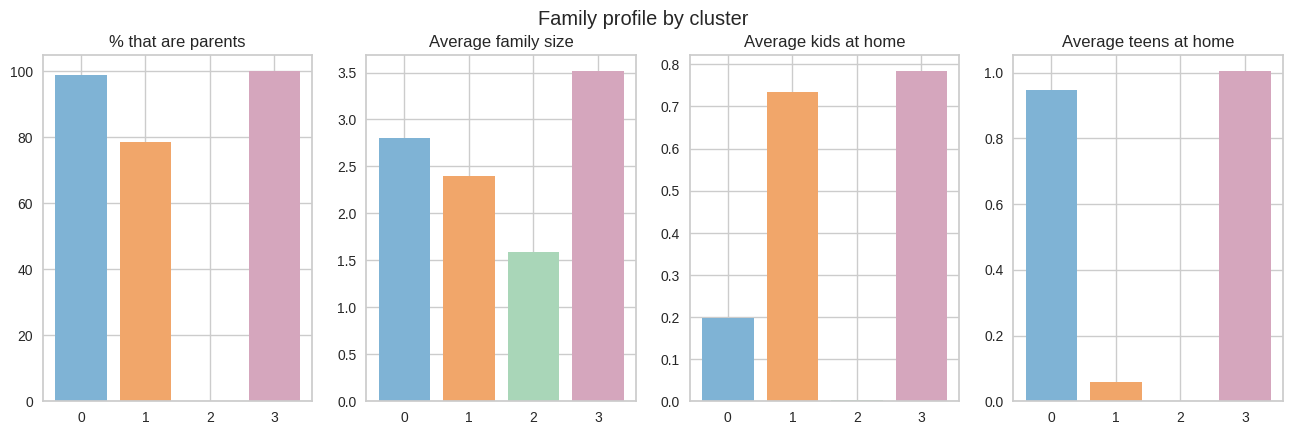

In [63]:
metrics = [
    ("Is_Parent", "% that are parents", True),
    ("Family_Size", "Average family size", False),
    ("Kidhome", "Average kids at home", False),
    ("Teenhome", "Average teens at home", False),
]

fig, axes = plt.subplots(1, 4, figsize=(16,4.5))
for ax, (col, title, is_pct) in zip(axes, metrics):
    vals = data.groupby("Clusters")[col].mean()
    if is_pct:
        vals = vals * 100
    ax.bar(vals.index.astype(str), vals.values, color=pall)
    ax.set_title(title)
plt.suptitle("Family profile by cluster")
plt.show()

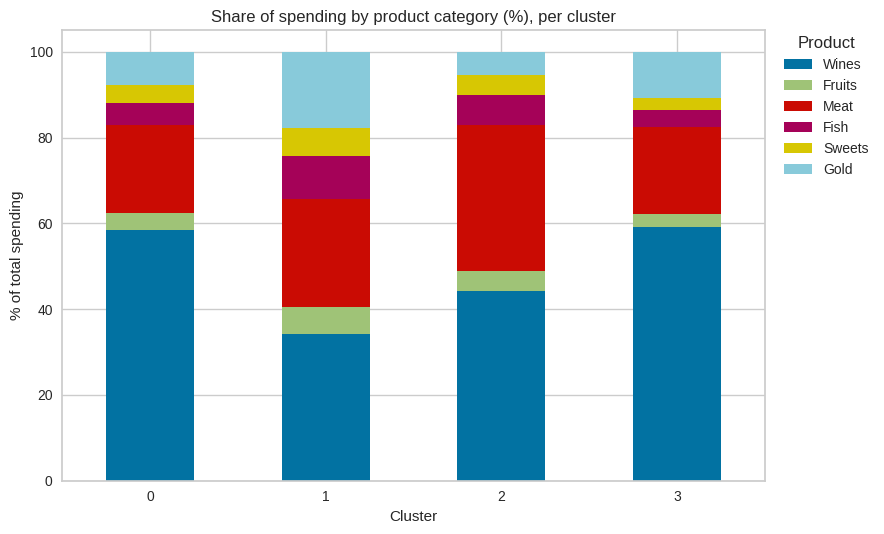

In [69]:
products = ["Wines", "Fruits", "Meat", "Fish", "Sweets", "Gold"]
share = data.groupby("Clusters")[products].mean()
share_pct = share.div(share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9,5.5))
share_pct.plot(kind="bar", stacked=True, ax=ax)

plt.title("Share of spending by product category (%), per cluster")
plt.ylabel("% of total spending")
plt.xlabel("Cluster")
plt.xticks(rotation=0)

ax.legend(title="Product", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

### PROFILING

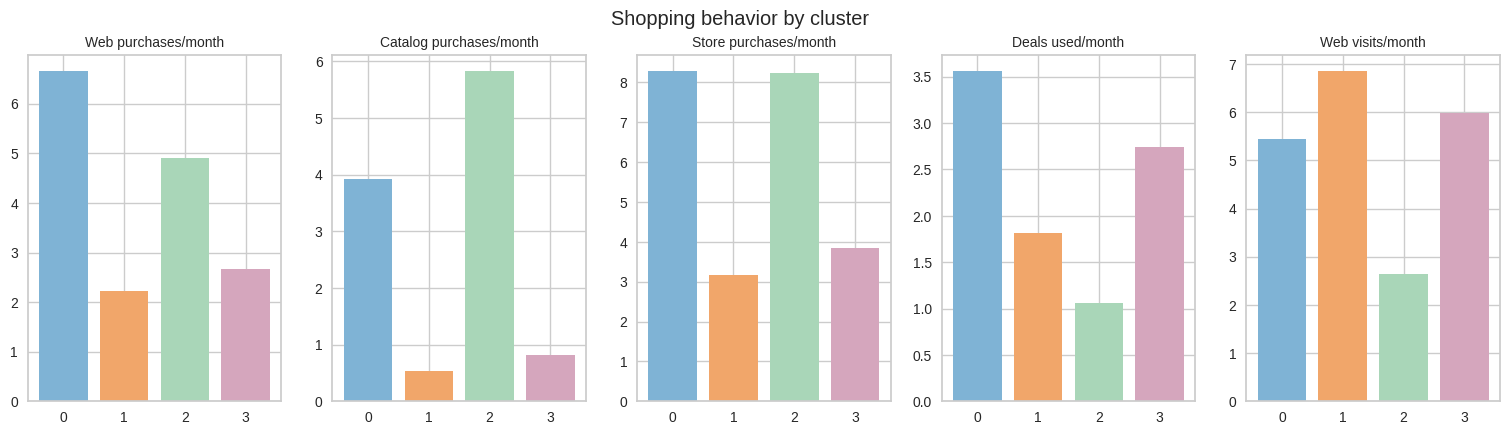

In [70]:
channels = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases", "NumWebVisitsMonth"]
titles = ["Web purchases/month", "Catalog purchases/month", "Store purchases/month", "Deals used/month", "Web visits/month"]

fig, axes = plt.subplots(1, 5, figsize=(19,4.5))
for ax, col, title in zip(axes, channels, titles):
    vals = data.groupby("Clusters")[col].mean()
    ax.bar(vals.index.astype(str), vals.values, color=pall)
    ax.set_title(title, fontsize=10)
plt.suptitle("Shopping behavior by cluster")
plt.show()

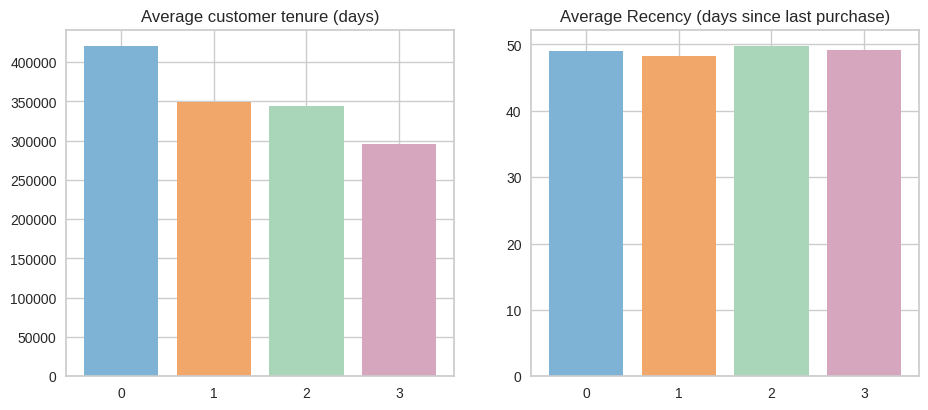

In [77]:
data["Customer_For_days"] = data["Customer_For"] / (86400*1e6)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

vals = data.groupby("Clusters")["Customer_For_days"].mean()
axes[0].bar(vals.index.astype(str), vals.values, color=pall)
axes[0].set_title("Average customer tenure (days)")

vals2 = data.groupby("Clusters")["Recency"].mean()
axes[1].bar(vals2.index.astype(str), vals2.values, color=pall)
axes[1].set_title("Average Recency (days since last purchase)")
plt.show()

# Profiling The Clusters
*Unsupervised Clustering Analysis*

Cluster labels are arbitrary identifiers and don't carry inherent meaning on their own. Each description reflects the actual patterns found in this run.

---

## Cluster 0

Almost entirely parents, with above-average income and spending, and wine as their dominant category. Highly active online and the most responsive to discounts of any group. The longest average tenure.

---

## Cluster 1

Mostly parents, with the lowest income and lowest spending of all groups. Visit the website the most but convert the least.

---

## Cluster 2

Almost no children at home, mostly singles or couples. Highest income and by far the highest spending. Basket leans toward meat over wine. Buy mainly through catalog and in-store, rarely use discounts, and rarely visit the website.

---

## Cluster 3
The largest average family size of the four. Below-average income and low spending, though wine still makes up their largest category share. Rely on discounts more than most, and are the newest customer segment.

### CONCLUSION

In this project, I performed unsupervised clustering.
I did use dimensionality reduction followed by agglomerative clustering.
I came up with 4 clusters and further used them in profiling customers in clusters according to their family structures and income/spending.
This can be used in planning better marketing strategies.